The dataset used in this notebook simulates the financial and ESG (Environmental, Social, and Governance) performance of 1,000 global companies across 9 industries and 7 regions from 2015 to 2025.

| Column Name | Description | Type |
|------------|-------------|------|
| CompanyID | Unique identifier for each synthetic company | Numeric |
| CompanyName | Synthetic company name (e.g., Company_123) | Categorical |
| Industry | Industry sector (e.g., Technology, Finance, Energy) | Categorical |
| Region | Geographic region (e.g., North America, Europe) | Categorical |
| Year | Reporting year (2015–2025) | Numeric |
| Revenue | Annual revenue in millions USD | Numeric |
| ProfitMargin | Net profit margin as a percentage of revenue | Numeric |
| MarketCap | Market capitalization in millions USD | Numeric |
| GrowthRate | Year-over-year revenue growth rate (%) | Numeric (NaN for 2015) |
| ESG_Overall | Aggregate ESG sustainability score (0–100) | Numeric |
| ESG_Environmental | Environmental sustainability score (0–100) | Numeric |
| ESG_Social | Social responsibility score (0–100) | Numeric |
| ESG_Governance | Corporate governance quality score (0–100) | Numeric |
| CarbonEmissions | Annual carbon emissions in tons CO₂ | Numeric |
| WaterUsage | Annual water usage in cubic meters | Numeric |
| EnergyConsumption | Annual energy consumption in megawatt-hours (MWh) | Numeric |


**Dataset Link:** https://www.kaggle.com/datasets/shriyashjagtap/esg-and-financial-performance-dataset

**Business Question:**

Can we automatically discover different types of companies based on financial performance and ESG behavior, and identify which clusters represent attractive investment opportunities?

In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv("/content/company_esg_financial_dataset.csv")

In [5]:
df.sample(7)

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
179,17,Company_17,Utilities,Oceania,2018,3910.5,13.4,4504.2,1.4,65.2,59.6,89.8,46.2,2448835.7,1530522.3,24488357.2
3038,277,Company_277,Transportation,Middle East,2017,454.9,5.4,446.5,-3.9,38.1,69.6,39.6,5.2,194522.5,32420.4,648408.2
3719,339,Company_339,Finance,Europe,2016,2313.1,13.8,3475.5,9.3,70.6,62.4,69.1,80.3,35303.1,17651.6,88257.9
7074,644,Company_644,Transportation,Africa,2016,1031.9,11.0,1993.9,-9.7,29.0,20.6,48.3,18.2,653517.7,108919.6,2178392.2
1379,126,Company_126,Manufacturing,Oceania,2019,2899.5,4.7,1105.6,20.5,44.5,23.2,59.2,51.1,902372.8,1203163.8,15039547.1
2476,226,Company_226,Healthcare,Middle East,2016,3141.4,23.0,12892.1,1.0,23.8,59.1,3.0,9.4,246999.1,246999.1,493998.1
10515,956,Company_956,Finance,Oceania,2025,5813.1,16.2,15794.5,5.0,60.0,97.1,45.7,37.1,60488.9,30244.5,151222.3


In [6]:
df.shape

(11000, 16)

In [7]:
df.columns

Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue',
       'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [9]:
df.describe()

,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09



# Check Data Quality

In [10]:
df.isnull().sum()

,0
CompanyID,0
CompanyName,0
Industry,0
Region,0
Year,0
Revenue,0
ProfitMargin,0
MarketCap,0
GrowthRate,1000
ESG_Overall,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Unique industries
df['Industry'].value_counts()

,count
Industry,
Healthcare,1331
Manufacturing,1287
Transportation,1287
Consumer Goods,1276
Finance,1243
Energy,1188
Utilities,1177
Retail,1166
Technology,1045


In [13]:
# Unique Regions
df['Region'].value_counts()

,count
Region,
Asia,1672
Oceania,1661
Middle East,1617
Europe,1540
North America,1540
Latin America,1507
Africa,1463


#Create a Clean Modeling Dataset

In [14]:
clustering_df = df.copy()

In [15]:
# Handle missing growth rate
clustering_df['GrowthRate'] = clustering_df['GrowthRate'].fillna(
    clustering_df['GrowthRate'].median()
)

In [16]:
# verify missing values
clustering_df.isnull().sum()

,0
CompanyID,0
CompanyName,0
Industry,0
Region,0
Year,0
Revenue,0
ProfitMargin,0
MarketCap,0
GrowthRate,0
ESG_Overall,0


For clustering, we are not going to use 'CompanyID', 'CompanyName' and 'Year' features.

In [17]:
# select features for clustering
features = [
    'Revenue',
    'ProfitMargin',
    'MarketCap',
    'GrowthRate',
    'ESG_Overall',
    'CarbonEmissions',
    'WaterUsage',
    'EnergyConsumption'
]

array([[<Axes: title={'center': 'Revenue'}>,
        <Axes: title={'center': 'ProfitMargin'}>,
        <Axes: title={'center': 'MarketCap'}>],
       [<Axes: title={'center': 'GrowthRate'}>,
        <Axes: title={'center': 'ESG_Overall'}>,
        <Axes: title={'center': 'CarbonEmissions'}>],
       [<Axes: title={'center': 'WaterUsage'}>,
        <Axes: title={'center': 'EnergyConsumption'}>, <Axes: >]],
      dtype=object)

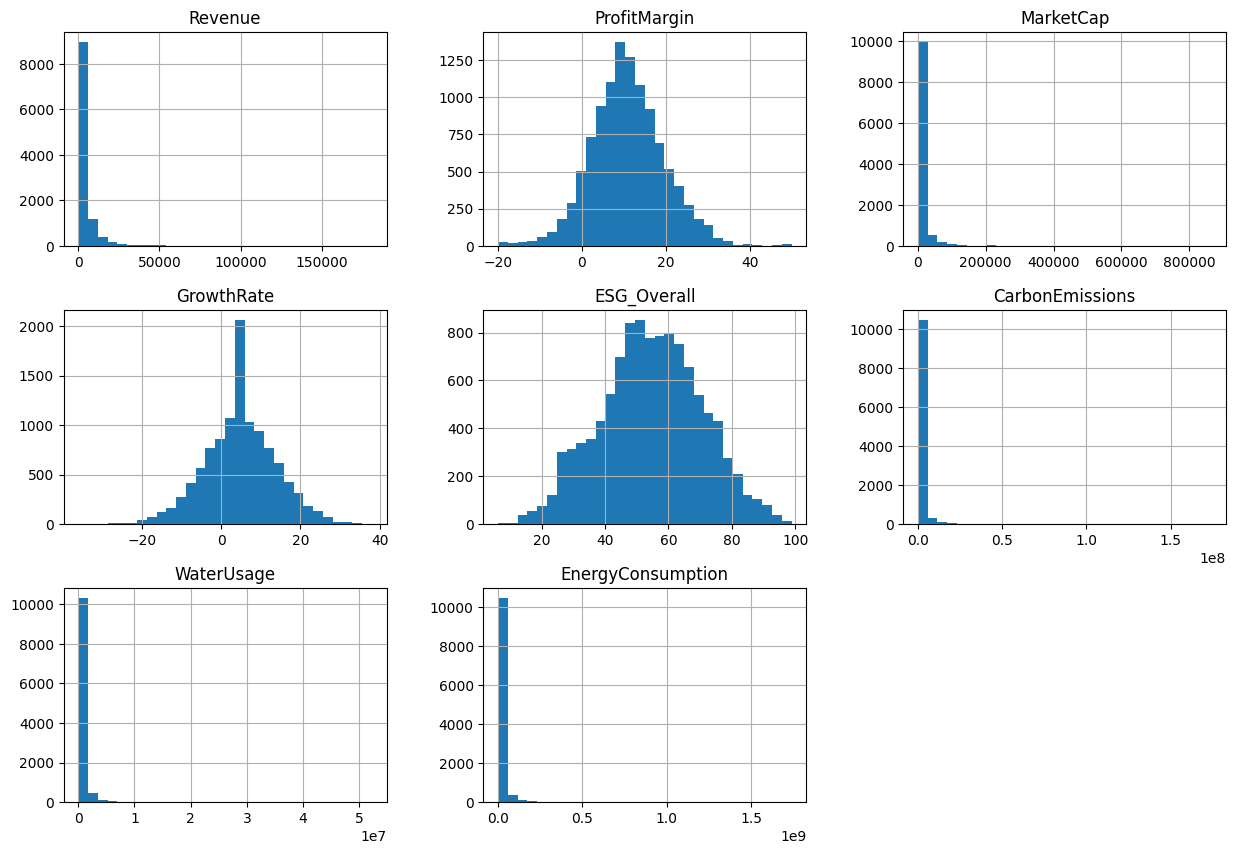

In [18]:
# Check Distribution Before Scaling
clustering_df[features].hist(
    figsize=(15,10),
    bins=30
)

In [19]:
clustering_df[features].describe()

,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,4670.850591,10.900455,13380.622236,4.836700,54.615273,1.271462e+06,5.600442e+05,1.165839e+07
std,9969.954369,8.758711,39922.870373,8.986164,15.893937,5.067760e+06,1.565686e+06,5.095836e+07
min,35.900000,-20.000000,1.800000,-36.000000,6.300000,2.042200e+03,1.021100e+03,5.105500e+03
25%,938.775000,5.300000,1098.525000,-0.600000,44.100000,1.228530e+05,6.488467e+04,3.069161e+05
50%,1902.300000,10.500000,3096.450000,4.900000,54.600000,2.920734e+05,2.038805e+05,1.221745e+06
75%,4342.625000,16.300000,9995.500000,10.300000,65.600000,7.407311e+05,5.251880e+05,5.616437e+06
max,180810.400000,50.000000,865271.700000,38.000000,98.800000,1.741047e+08,5.223142e+07,1.741047e+09


In [20]:
# create new dataframe
model_df = clustering_df.copy()

#Data Preprocessing
Perform logarithmic normalization to handle extreme financial and environmental outliers before clustering 11,000 companies.

### Log transformation:

In [21]:
# Apply log transformation on skewed columns
skewed_cols = [
    'Revenue',
    'MarketCap',
    'CarbonEmissions',
    'WaterUsage',
    'EnergyConsumption'
]

for col in skewed_cols:
    model_df[col] = np.log1p(model_df[col])

array([[<Axes: title={'center': 'Revenue'}>,
        <Axes: title={'center': 'MarketCap'}>],
       [<Axes: title={'center': 'CarbonEmissions'}>,
        <Axes: title={'center': 'WaterUsage'}>],
       [<Axes: title={'center': 'EnergyConsumption'}>, <Axes: >]],
      dtype=object)

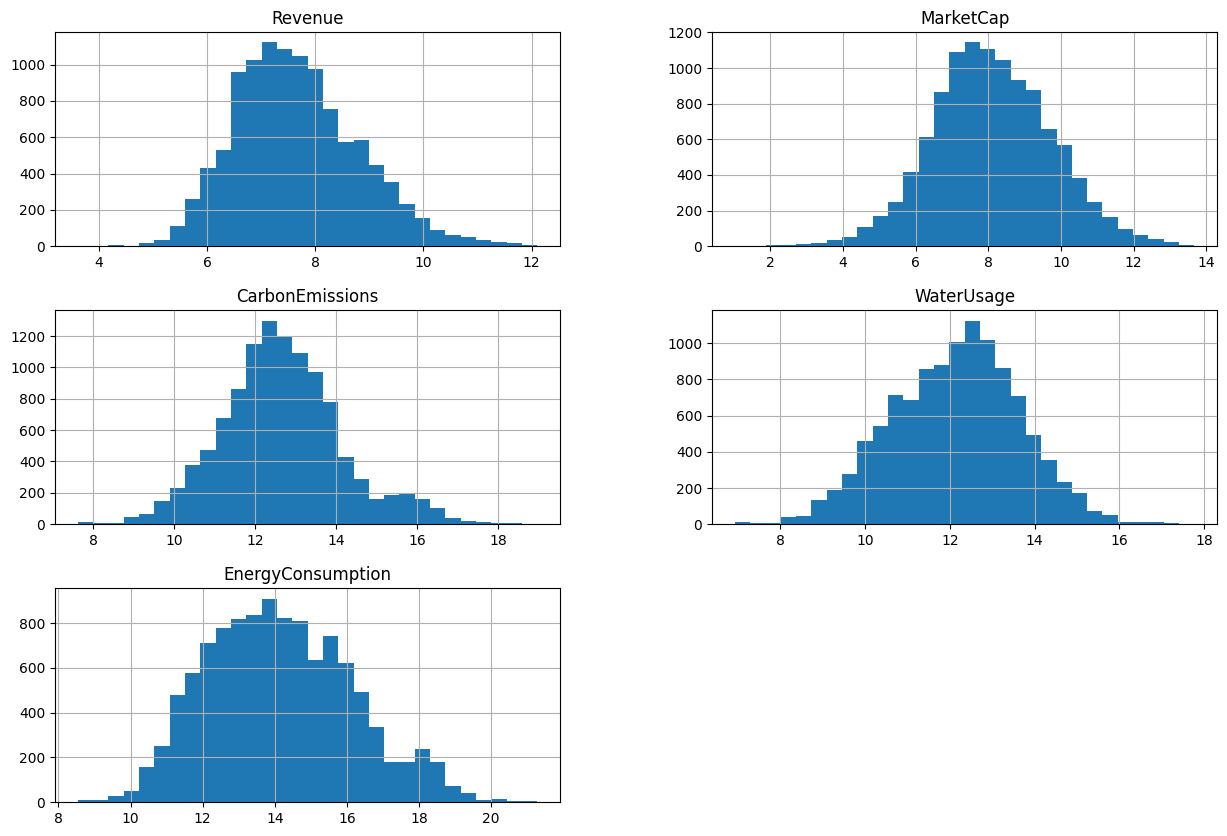

In [22]:
# skewed to smoother distribution
model_df[skewed_cols].hist(
    figsize=(15,10),
    bins=30
)

### Standardization:

Now every feature still has different scales.

**Example:**

- ProfitMargin  : -20 to 50
- GrowthRate    : -36 to 38
- ESG           : 6 to 99
- Revenue(log)  : 4 to 12

K-Means uses distance calculations.

If features are not standardized, some features influence clustering more than others

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    model_df[features]
)

In [24]:
scaled_data.shape

(11000, 8)

8 clustering features exist.
#Find the Best Number of Clusters: Elbow Method

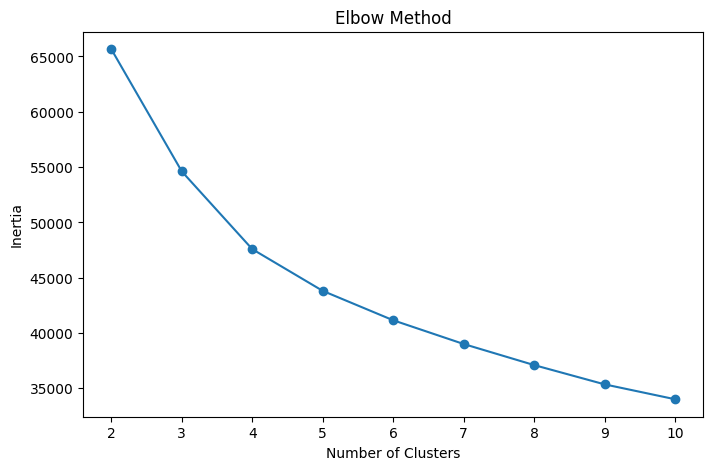

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [26]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        scaled_data
    )

    score = silhouette_score(
        scaled_data,
        labels
    )

    scores.append(score)

for k, score in zip(range(2,11), scores):
    print(f"K={k}: {score:.4f}")

K=2: 0.2201
K=3: 0.2028
K=4: 0.2079
K=5: 0.1788
K=6: 0.1630
K=7: 0.1527
K=8: 0.1535
K=9: 0.1552
K=10: 0.1542


We choose k=4, as it is
statistically:
- Close to elbow point
- Silhouette still reasonable

# Model Training

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_data
)

model_df['Cluster'] = clusters

In [28]:
model_df['Cluster'].value_counts()

,count
Cluster,
2,4378
3,2586
1,2338
0,1698


# PCA visualization

In [29]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

pca_features = pca.fit_transform(
    scaled_data
)

model_df['PCA1'] = pca_features[:,0]
model_df['PCA2'] = pca_features[:,1]

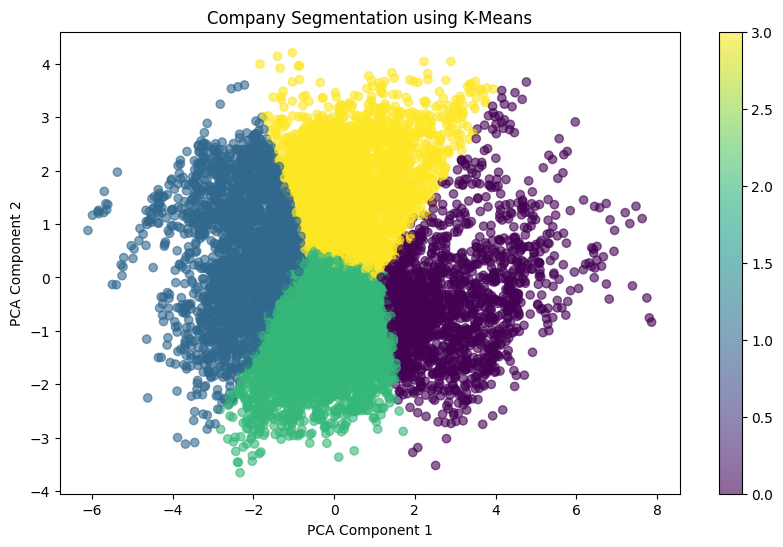

In [30]:
# Cluster plotting

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    model_df['PCA1'],
    model_df['PCA2'],
    c=model_df['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Company Segmentation using K-Means')

plt.colorbar(scatter)

plt.show()

# Cluster Profile

In [31]:
cluster_profile = model_df.groupby('Cluster')[
    [
        'Revenue',
        'ProfitMargin',
        'MarketCap',
        'GrowthRate',
        'ESG_Overall',
        'CarbonEmissions',
        'WaterUsage',
        'EnergyConsumption'
    ]
].mean()

cluster_profile

,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,CarbonEmissions,WaterUsage,EnergyConsumption
Cluster,,,,,,,,
0,8.782644,11.376148,9.316360,5.729034,49.113722,15.022076,14.333301,17.248813
1,6.982320,10.108212,7.297624,3.281523,60.346022,10.831759,10.209251,11.696123
2,6.989993,7.243741,7.065720,3.125605,49.075879,12.886736,12.347576,14.780389
3,8.698594,17.495050,9.810350,8.553635,62.424478,12.411055,12.081340,13.250712


In [32]:
# Check Industry Distribution
pd.crosstab(
    model_df['Cluster'],
    df['Industry']
)

Industry,Consumer Goods,Energy,Finance,Healthcare,Manufacturing,Retail,Technology,Transportation,Utilities
Cluster,,,,,,,,,
0,111,920,0,58,345,1,52,45,166
1,101,14,742,295,16,895,120,149,6
2,823,249,0,144,914,175,0,1068,1005
3,241,5,501,834,12,95,873,25,0


In [33]:
# Region Distribution
pd.crosstab(
    model_df['Cluster'],
    df['Region']
)

Region,Africa,Asia,Europe,Latin America,Middle East,North America,Oceania
Cluster,,,,,,,
0,246,233,240,250,247,219,263
1,316,383,387,322,288,301,341
2,595,711,487,652,663,619,651
3,306,345,426,283,419,401,406


### **Cluster 0:**

Metric	Observation:
- Revenue  (High)
- MarketCap	(High)
- GrowthRate	(High)
- ESG	(Low)
- Carbon	(Highest)
- Water	(Highest)
- Energy	(Highest)

Cluster Name:

**Resource Intensive Giants**

Examples in real life:

- Oil companies
- Heavy manufacturing
- Mining firms
- Utilities

------------------------------------
------------------------------------
## **Cluster 1**

Metric	Observation:

- Revenue	(Low)
- MarketCap	(Low)
- Growth	(Moderate)
- ESG	(High)
- Emissions	(Lowest)
- Water	(Lowest)
- Energy	(Lowest)

Cluster Name:

**Sustainable Service Firms**

Examples:

- Banks
- Insurance
- Retail chains
- Asset management firms

------------------------------------
------------------------------------

## **Cluster 2**

Metric	Observation:

- Revenue	(Low)
- MarketCap	(Lowest)
- Profit Margin	(Lowest)
- Growth	(Lowest)
- ESG	(Low)

Cluster Name:

**Traditional Operators**

---------------------------------
---------------------------------

## **Cluster 3**

Metric	Observation:

- Profit Margin	(Highest)
- Growth Rate	(Highest)
- Market Cap	(High)
- ESG	(Highest)

Cluster Name:

**High-Performance Innovators**

In [34]:
# create cluster profile
cluster_names = {
    0: "Resource Intensive Giants",
    1: "Sustainable Service Firms",
    2: "Traditional Operators",
    3: "High-Performance Innovators"
}

model_df["Cluster_Name"] = model_df["Cluster"].map(
    cluster_names
)


In [35]:
# create summary table
summary = model_df.groupby(
    "Cluster_Name"
).agg({
    "Revenue":"mean",
    "ProfitMargin":"mean",
    "MarketCap":"mean",
    "GrowthRate":"mean",
    "ESG_Overall":"mean"
})

summary

,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall
Cluster_Name,,,,,
High-Performance Innovators,8.698594,17.495050,9.810350,8.553635,62.424478
Resource Intensive Giants,8.782644,11.376148,9.316360,5.729034,49.113722
Sustainable Service Firms,6.982320,10.108212,7.297624,3.281523,60.346022
Traditional Operators,6.989993,7.243741,7.065720,3.125605,49.075879


**Cluster	Description:**

- High-Performance Innovators: High profit, high growth, high ESG
- Resource Intensive Giants: High revenue, high market cap, high resource - consumption
- Sustainable Service Firms: High ESG, low environmental footprint
- Traditional Operators: Low growth, low profit, lower ESG maturity

**Regression based Model training** to predict Company Persona(category) based on financial and ESG metrics.

In [36]:
y = model_df["Cluster"]

X = model_df[
    [
        'Revenue',
        'ProfitMargin',
        'MarketCap',
        'GrowthRate',
        'ESG_Overall',
        'CarbonEmissions',
        'WaterUsage',
        'EnergyConsumption'
    ]
]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
# Train RandomForest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=300, random_state=42)

In [40]:
y_pred = rf.predict(X_test)

In [41]:
# Evaluate
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    y_pred
)

0.9704545454545455

In [42]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       340
           1       0.98      0.97      0.97       468
           2       0.97      0.98      0.98       875
           3       0.97      0.95      0.96       517

    accuracy                           0.97      2200
   macro avg       0.97      0.97      0.97      2200
weighted avg       0.97      0.97      0.97      2200



The Random Forest successfully learned the clustering structure discovered by K-Means and can rapidly assign new companies to discovered business personas.

In [43]:
import pandas as pd

importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    }
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,EnergyConsumption,0.244044
2,MarketCap,0.176991
5,CarbonEmissions,0.176814
6,WaterUsage,0.154516
0,Revenue,0.135413
1,ProfitMargin,0.050953
4,ESG_Overall,0.040038
3,GrowthRate,0.021230


Our clustering is primarily separating companies by Resource Intensity
rather than Financial Performance.

In [44]:
import joblib

joblib.dump(rf, "company_persona_classifier.pkl")

['company_persona_classifier.pkl']

In [45]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']